In [6]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch import nn
from typing import Any, Dict, Optional, Union
from tqdm import tqdm
import json
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


from causalflows.flows import CausalMAF, CausalNSF
from causalflows.scms import SCM, CausalEquations

In [12]:
variables

['age',
 'bmi',
 'cardiac ischemia',
 'diabetes mellitus',
 'diastolic pressure',
 'major acute cardiovascular event',
 'systolic pressure']

## Import our Knowledge graphs

#NOTE we need to put 1 in the diagonal of the adjacency matrix

In [2]:
with open("new_ordered_graphs.json", 'r', encoding='utf-8') as f:
    loaded_graphs = json.load(f)

selected_graph = loaded_graphs[0]  
variables = selected_graph['variables']
adjacency_matrix = selected_graph['adjacency_matrix']

adj_array = np.array(adjacency_matrix)
# Add ones to the diagonal
np.fill_diagonal(adj_array, 1)

# Convert to torch tensor (boolean)
adjacency = torch.tensor(adj_array, dtype=torch.bool)
adjacency

tensor([[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [False, False,  True, False, False, False, False],
        [False,  True, False,  True, False, False, False],
        [ True,  True, False,  True,  True, False, False],
        [ True,  True, False,  True, False,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]])

## Import our diabetes dataset

In [7]:
data_df = pd.read_csv("TFM_dataset.csv")

# Drop patient ID column 
data_df = data_df.drop(columns=['randid'])

data_df = data_df[variables]

# Fill missing BMI values with mode
bmi_mode = data_df['bmi'].mode()[0]
data_df['bmi'] = data_df['bmi'].fillna(bmi_mode)


Check if NaNs in the data and handle them accordingly

In [4]:
data_df.isna().sum()

age                                 0
bmi                                 0
cardiac ischemia                    0
diabetes mellitus                   0
diastolic pressure                  0
systolic pressure                   0
major acute cardiovascular event    0
dtype: int64

In [8]:
diabetes_idx = variables.index('diabetes mellitus')

total_diabetes = (data_df['diabetes mellitus'] == 1).sum()
total_no_diabetes = (data_df['diabetes mellitus'] == 0).sum()
print(f" Total dataset:")
print(f"   Diabetes = 1: {total_diabetes} ({total_diabetes/len(data_df)*100:.1f}%)")
print(f"   Diabetes = 0: {total_no_diabetes} ({total_no_diabetes/len(data_df)*100:.1f}%)")

 Total dataset:
   Diabetes = 1: 121 (2.7%)
   Diabetes = 0: 4313 (97.3%)


In [9]:

# Identify binary variables
binary_vars = []
for col in data_df.columns:
    unique_vals = sorted(data_df[col].unique())
    if len(unique_vals) == 2 and set(unique_vals).issubset({0.0, 1.0}):
        binary_vars.append(col)
        prop = (data_df[col] == 1).mean()
        print(f"Binary variable: {col:40s}: {prop:.1%}")

continuous_vars = [col for col in data_df.columns if col not in binary_vars]

# Prepare data
data_processed = data_df.copy()
np.random.seed(42)

# Add noise ONLY for training the flow (not for scaler)
data_for_training = data_df.copy()
for col in binary_vars:
    noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
    noise = np.random.normal(0, noise_std, size=len(data_df))
    data_for_training[col] = data_df[col].astype(float) + noise

# SCALER ONLY FOR CONTINUOUS VARIABLES
scaler = StandardScaler()
data_normalized = data_df.copy()

# Normalize only continuous variables
if len(continuous_vars) > 0:
    continuous_indices = [data_df.columns.get_loc(c) for c in continuous_vars]
    data_normalized.iloc[:, continuous_indices] = scaler.fit_transform(
        data_df.iloc[:, continuous_indices]
    )

# Add noise to binary variables AFTER fitting scaler
for col in binary_vars:
    noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
    noise = np.random.normal(0, noise_std, size=len(data_df))
    data_normalized[col] = data_df[col].astype(float) + noise

# STRATIFIED SPLIT
diabetes_labels = data_df['diabetes mellitus'].values

train_idx, test_idx = train_test_split(
    np.arange(len(data_normalized)),
    test_size=0.1,
    stratify=diabetes_labels,
    random_state=42
)

# Tensors
data_tensor = torch.tensor(data_normalized.values, dtype=torch.float32)

Binary variable: cardiac ischemia                        : 16.5%
Binary variable: diabetes mellitus                       : 2.7%
Binary variable: major acute cardiovascular event        : 26.1%


/tmp/ipykernel_30374/2252277692.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.25932027 -0.45249227 -0.22196998 ...  0.23907459 -1.14405912
 -1.25932027]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler.fit_transform(
/tmp/ipykernel_30374/2252277692.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.09245627 -0.17959929 -0.26258628 ... -0.01362529  1.23117969
  0.23533571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler.fit_transform(
/tmp/ipykernel_30374/2252277692.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.20464005e+00 -5.35512949e-01 -2.23253637e-01 ...  4

In [10]:
train_data = data_tensor[train_idx]
test_data = data_tensor[test_idx]

features = len(variables)

#context number of additional variables
context = 0


In [11]:
TensorLike = Union[torch.Tensor, Dataset]

def _make_loader(data: TensorLike, batch_size: int, shuffle: bool) -> DataLoader:
    if isinstance(data, torch.Tensor):
        data = TensorDataset(data)
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)

@torch.no_grad()
def _eval_nll(flow: nn.Module, loader: DataLoader, device: torch.device) -> float:
    flow.eval()
    total, count = 0.0, 0
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        x = x.to(device)
        nll = -flow().log_prob(x)  # [B]
        total += float(nll.sum().item())
        count += x.shape[0]
    return total / max(count, 1)

def fit(
    flow: nn.Module,
    train_data: TensorLike,
    val_data: Optional[TensorLike] = None,
    *,
    lr: float = 1e-3,
    batch_size: int = 256,
    epochs: int = 100,
    device: Optional[torch.device] = None,
    print_every: int = 1,
    early_stopping_patience: int = 50,
    early_stopping_min_delta: float = 1e-4,
) -> Dict[str, Any]:
    """
    Minimal training loop for a flow model with .log_prob(x).

    Args:
        flow: nn.Module implementing log_prob(x) -> [B].
        train_data: Dataset or Tensor [N, D].
        val_data: optional Dataset or Tensor for validation.
        lr, batch_size, epochs: training hyperparameters.
        device: optional torch.device; defaults to 'cuda' if available else 'cpu'.
        print_every: print training progress every N epochs.
        early_stopping_patience: stop if val_nll doesn't improve for N epochs (0 = disabled).
        early_stopping_min_delta: minimum change to qualify as improvement.

    Returns:
        history dict with per-epoch train/val NLL and early stopping info.
    """
    dev = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    flow.to(dev)

    train_loader = _make_loader(train_data, batch_size, shuffle=True)
    val_loader = _make_loader(val_data, batch_size, shuffle=False) if val_data is not None else None

    optim = torch.optim.Adam(flow.parameters(), lr=lr)

    history = {
        "train_nll": [], 
        "val_nll": [] if val_loader is not None else None,
        "stopped_early": False,
        "best_epoch": 0
    }
    
    # Early stopping variables
    best_val_nll = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in tqdm(range(1, epochs + 1)):
        flow.train()
        running, seen = 0.0, 0

        for batch in train_loader:
            x = batch[0] if isinstance(batch, (tuple, list)) else batch
            x = x.to(dev, non_blocking=True)

            optim.zero_grad(set_to_none=True)
            loss = -flow().log_prob(x).mean()  # mean NLL over batch
            loss.backward()
            optim.step()

            running += float(loss.item()) * x.size(0)
            seen += x.size(0)

        train_nll = running / max(seen, 1)
        history["train_nll"].append(train_nll)

        if val_loader is not None:
            val_nll = _eval_nll(flow, val_loader, dev)
            history["val_nll"].append(val_nll)
            
            # Early stopping logic
            if early_stopping_patience > 0:
                if val_nll < best_val_nll - early_stopping_min_delta:
                    # Improvement found
                    best_val_nll = val_nll
                    patience_counter = 0
                    history["best_epoch"] = epoch
                    # Save best model state
                    best_model_state = {k: v.cpu().clone() for k, v in flow.state_dict().items()}
                else:
                    # No improvement
                    patience_counter += 1
                    
                if patience_counter >= early_stopping_patience:
                    if epoch % print_every == 0 or True:  # Always print early stopping message
                        print(f"[{epoch:03d}/{epochs:03d}] train_nll={train_nll:.4f}  val_nll={val_nll:.4f}")
                    history["stopped_early"] = True
                    # Restore best model
                    if best_model_state is not None:
                        flow.load_state_dict(best_model_state)
                        print(f"   Restored model from epoch {history['best_epoch']}")
                    break
            
            if epoch % print_every == 0:
                patience_str = f"  patience={patience_counter}/{early_stopping_patience}" if early_stopping_patience > 0 else ""
                print(f"[{epoch:03d}/{epochs:03d}] train_nll={train_nll:.4f}  val_nll={val_nll:.4f}{patience_str}")
        else:
            if epoch % print_every == 0:
                print(f"[{epoch:03d}/{epochs:03d}] train_nll={train_nll:.4f}")

    return history


In [20]:
cfg_balanced = {
    'hidden_dims': [64, 64],  
    'lr': 5e-4,               
    'batch_size': 128,       
    'epochs': 2000,         
}

In [ ]:
flow = CausalNSF(
    features, 
    context, 
    # here our graph
    adjacency=adjacency,
    hidden_features=cfg_balanced['hidden_dims']
)

history = fit(
    flow,
    train_data,
    val_data=test_data,
    lr=cfg_balanced['lr'],
    batch_size=cfg_balanced['batch_size'],
    epochs=cfg_balanced['epochs'],
    print_every=200,
)

  0%|          | 0/2000 [00:00<?, ?it/s]/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 10%|█         | 201/2000 [00:35<05:32,  5.41it/s]

[200/2000] train_nll=0.8913  val_nll=0.8912


 20%|██        | 401/2000 [01:11<04:26,  6.00it/s]

[400/2000] train_nll=0.8371  val_nll=0.9234


 30%|███       | 601/2000 [01:47<03:28,  6.72it/s]

...

[1600/2000] train_nll=0.6927  val_nll=1.0415


 90%|█████████ | 1801/2000 [05:19<00:29,  6.79it/s]

[1800/2000] train_nll=0.6666  val_nll=1.0301


100%|██████████| 2000/2000 [05:53<00:00,  5.66it/s]

[2000/2000] train_nll=0.6502  val_nll=1.0575


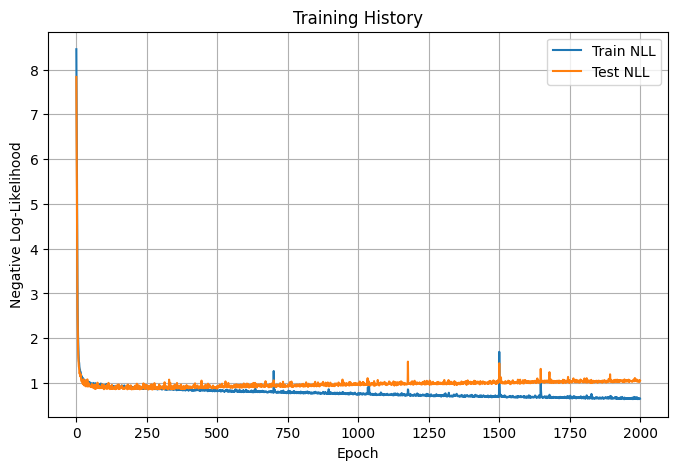

In [139]:
# plot history
plt.figure(figsize=(8, 5))
plt.plot(history['train_nll'], label='Train NLL')
plt.plot(history['val_nll'], label='Test NLL')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training History')
plt.legend()
plt.grid()
plt.show()

In [87]:
def plot_data(tensors_dict):
    df = create_df(tensors_dict)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    g.map_lower(sns.kdeplot, common_norm=False)
    g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    g.add_legend()
    plt.show()



In [ ]:
def create_df(tensors_dict):
    df_list = []
    for i, (k, x) in enumerate(tensors_dict.items()):
        #df = pd.DataFrame(x.numpy(), columns=[f'$x_{j}$' for j in range(x.shape[1])])
        df = pd.DataFrame(x.numpy(), columns=variables)
        df['name'] = k
        df_list.append(df)

    df = pd.concat(df_list)
    return df

In [123]:
test_size = test_data.shape[0]

gen_data new samples created by the model

**Plot comparing observational distribution and the flow distribution**

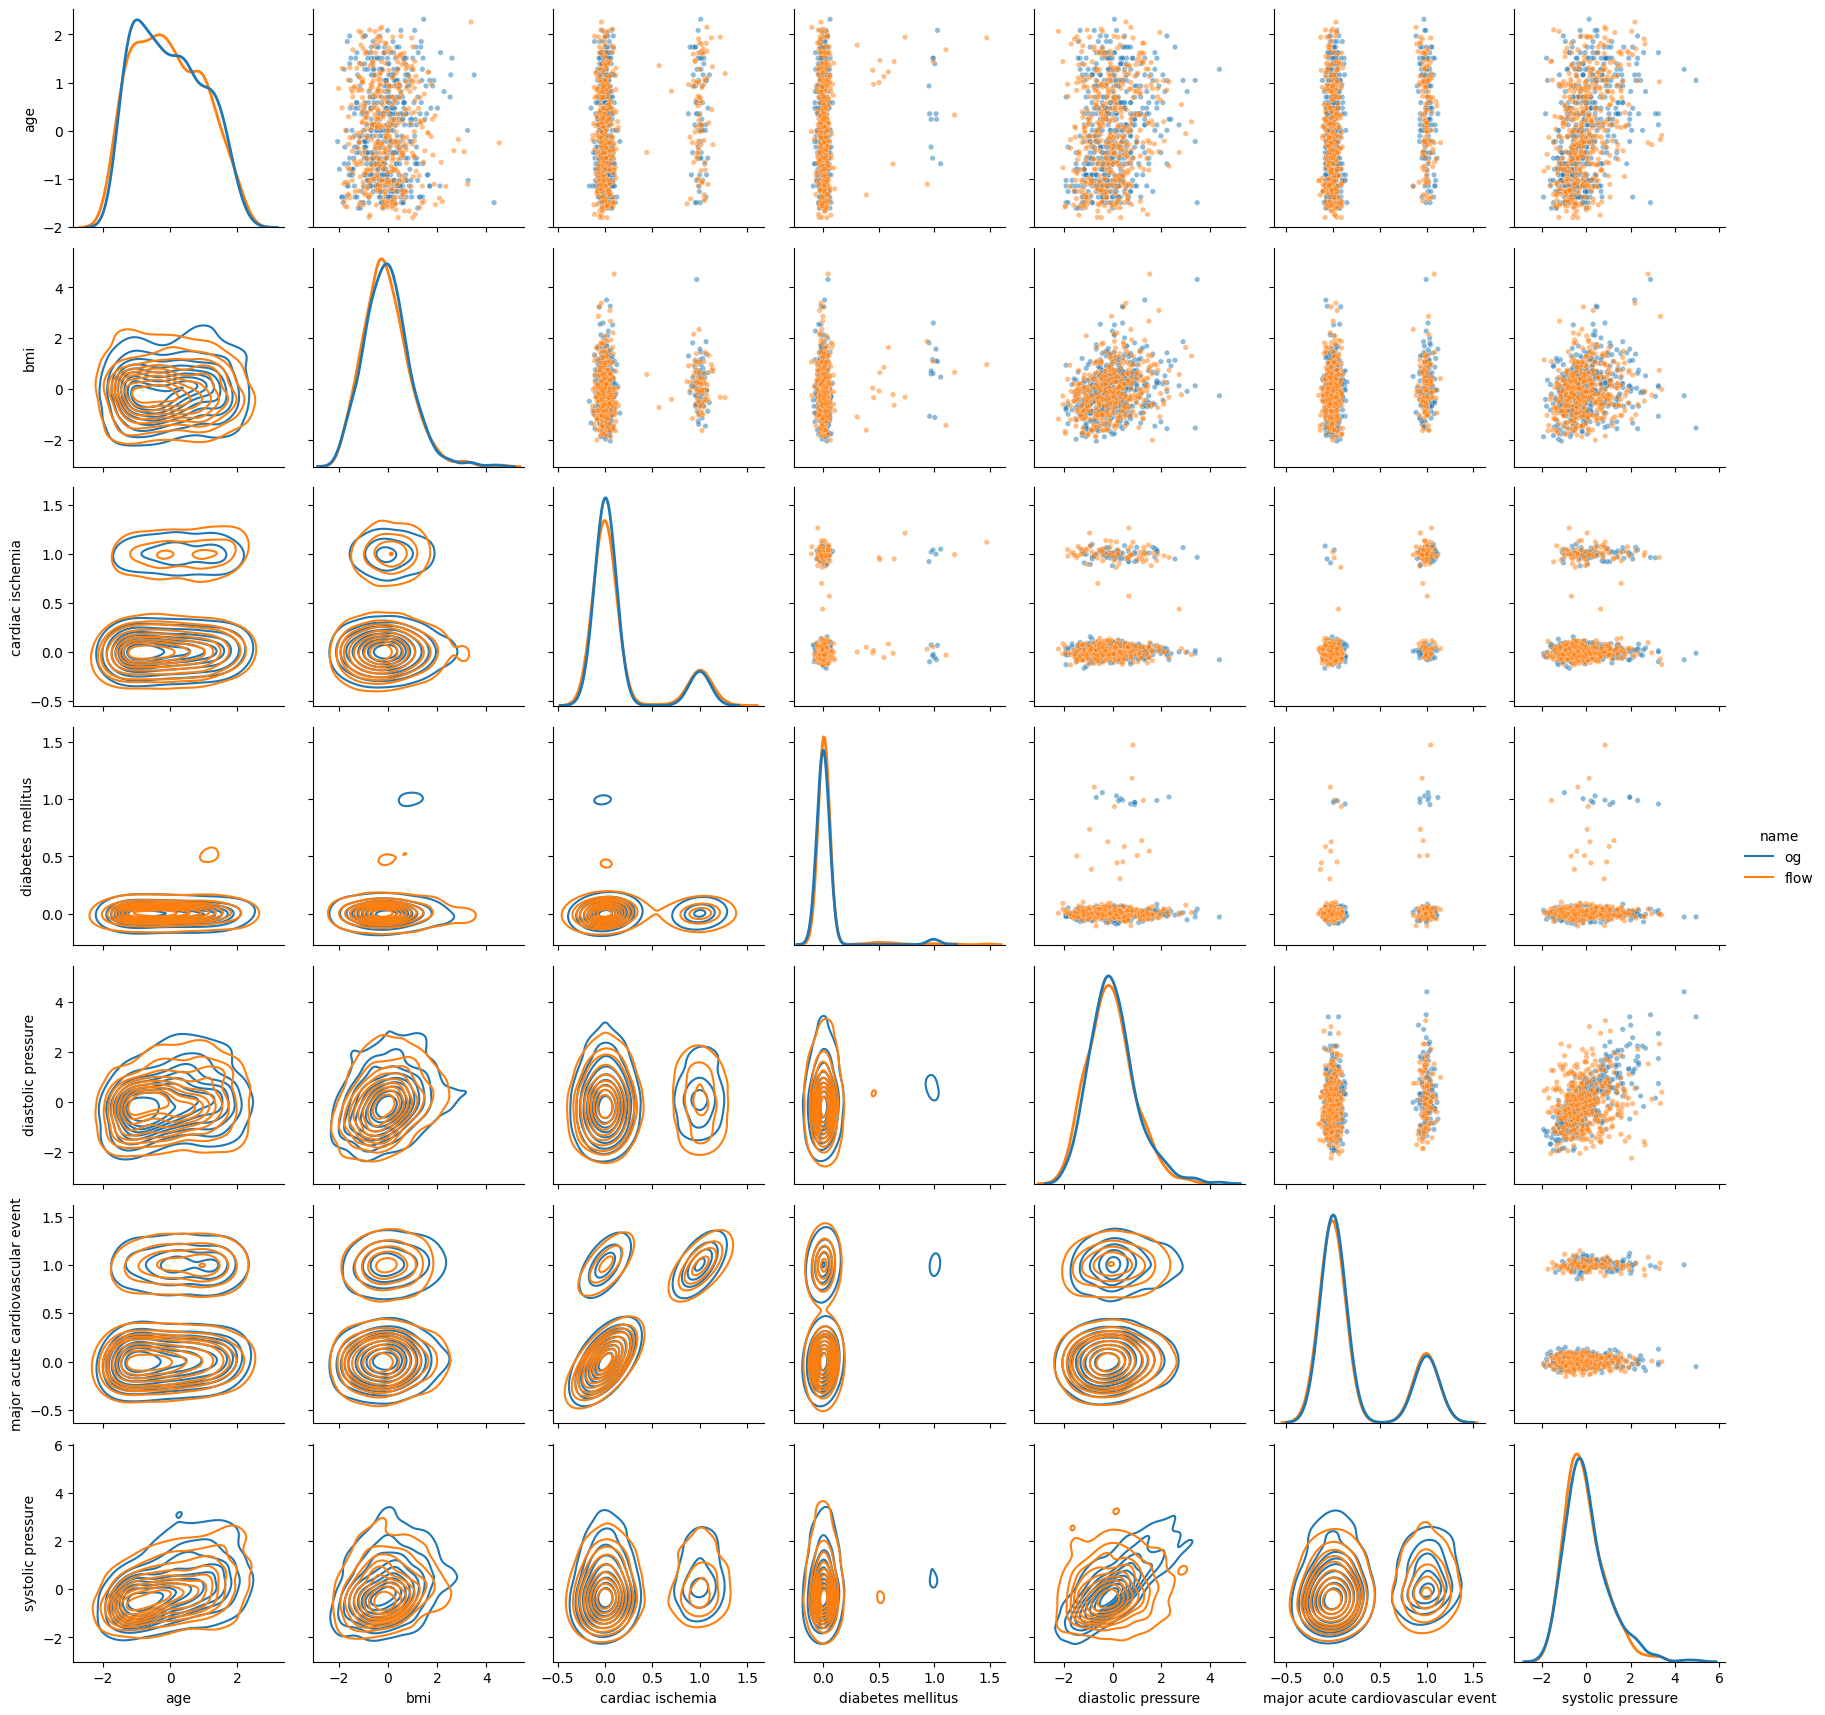

In [140]:
gen_data = flow().sample([test_size]) # ONLY FOR EXAMPLE
plot_data({'og': test_data, 'flow': gen_data}) # ONLY FOR EXAMPLE

In [14]:
with open("ground_truth_graph.json", 'r', encoding='utf-8') as f:
    ground_truth_data = json.load(f)

adjacency_gt = np.array(ground_truth_data['adjacency_matrix'])
np.fill_diagonal(adjacency_gt, 1)
adjacency_gt = torch.tensor(adjacency_gt, dtype=torch.bool)


añadir enlace sys dias

In [ ]:
flow_gt = CausalNSF(
    features, 
    context, 
    adjacency=adjacency_gt,  # Ground truth
    hidden_features=cfg_balanced['hidden_dims']
)

history_gt = fit(
    flow_gt,
    train_data,
    val_data=test_data,
    lr=cfg_balanced['lr'],
    batch_size=cfg_balanced['batch_size'],
    epochs=cfg_balanced['epochs'],
    print_every=200,
)

  0%|          | 0/2000 [00:00<?, ?it/s]/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 10%|█         | 200/2000 [00:33<05:13,  5.74it/s]

[200/2000] train_nll=0.3675  val_nll=0.4469


 20%|██        | 401/2000 [01:14<05:15,  5.06it/s]

[400/2000] train_nll=0.3646  val_nll=0.4325


 30%|███       | 600/2000 [01:55<04:47,  4.87it/s]

...

[1600/2000] train_nll=0.2055  val_nll=0.5182


 90%|█████████ | 1801/2000 [05:57<00:31,  6.34it/s]

[1800/2000] train_nll=0.2056  val_nll=0.4968


100%|██████████| 2000/2000 [06:28<00:00,  5.14it/s]

[2000/2000] train_nll=0.1945  val_nll=0.5162


Interventions

choosing one variable for instance bmi and see how it changes from not having obesity to obesity

In [172]:
intervention_var = 'bmi'  
intervention_index = variables.index(intervention_var)
# normalization done below we need to normalize the value this is for bmi aprox 30
intervention_value = 0.2832539622372572

# Generar datos observacionales (sin intervención)
gen_data_selected = flow().sample([test_size])
gen_data_gt = flow_gt().sample([test_size])

# Generar datos intervenidos en SELECTED graph
int_data_selected = flow().sample_interventional(
    index=intervention_index, 
    value=intervention_value, 
    sample_shape=(test_size,)
)

# Generar datos intervenidos en GROUND TRUTH graph
int_data_gt = flow_gt().sample_interventional(
    index=intervention_index, 
    value=intervention_value, 
    sample_shape=(test_size,)
)



preguntar a Juan donde hago la intervencion por que se ve asi

/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/home/moleropa/minif

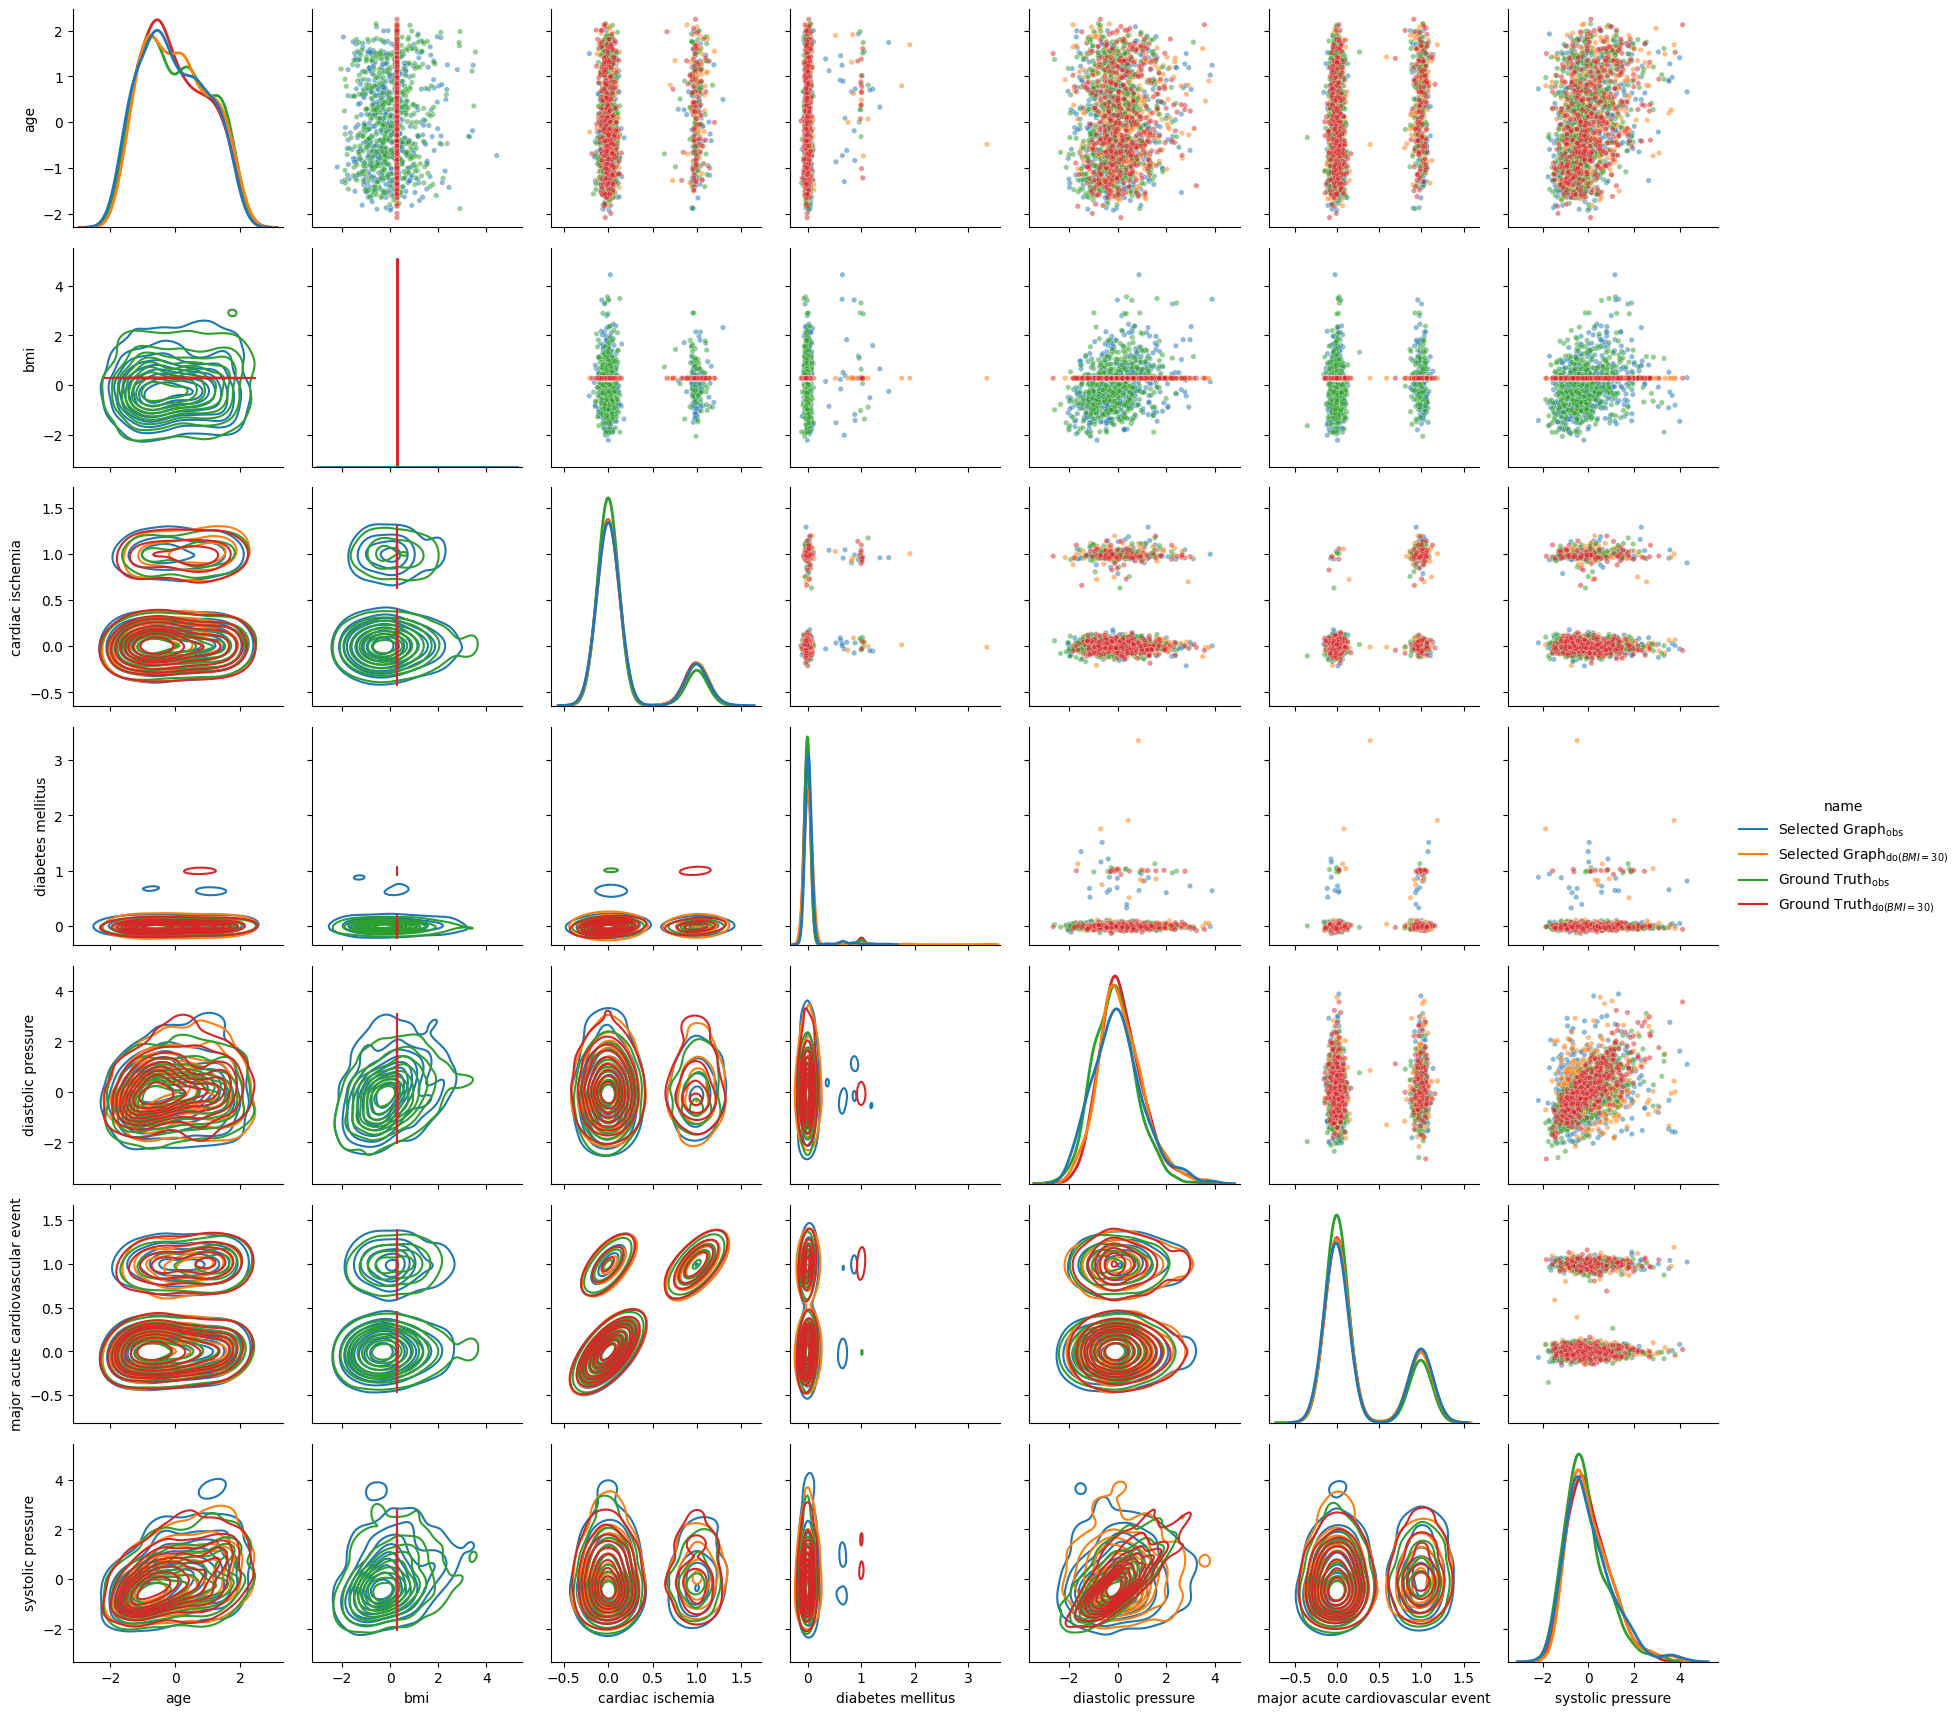

In [173]:
# bien
plot_data({
    r'$\text{Selected Graph}_{\text{obs}}$': gen_data_selected,
    r'$\text{Selected Graph}_{\mathrm{do}(BMI = 30)}$': int_data_selected,
    r'$\text{Ground Truth}_{\text{obs}}$': gen_data_gt,
    r'$\text{Ground Truth}_{\mathrm{do}(BMI = 30)}$': int_data_gt,#warn_singular=False
})


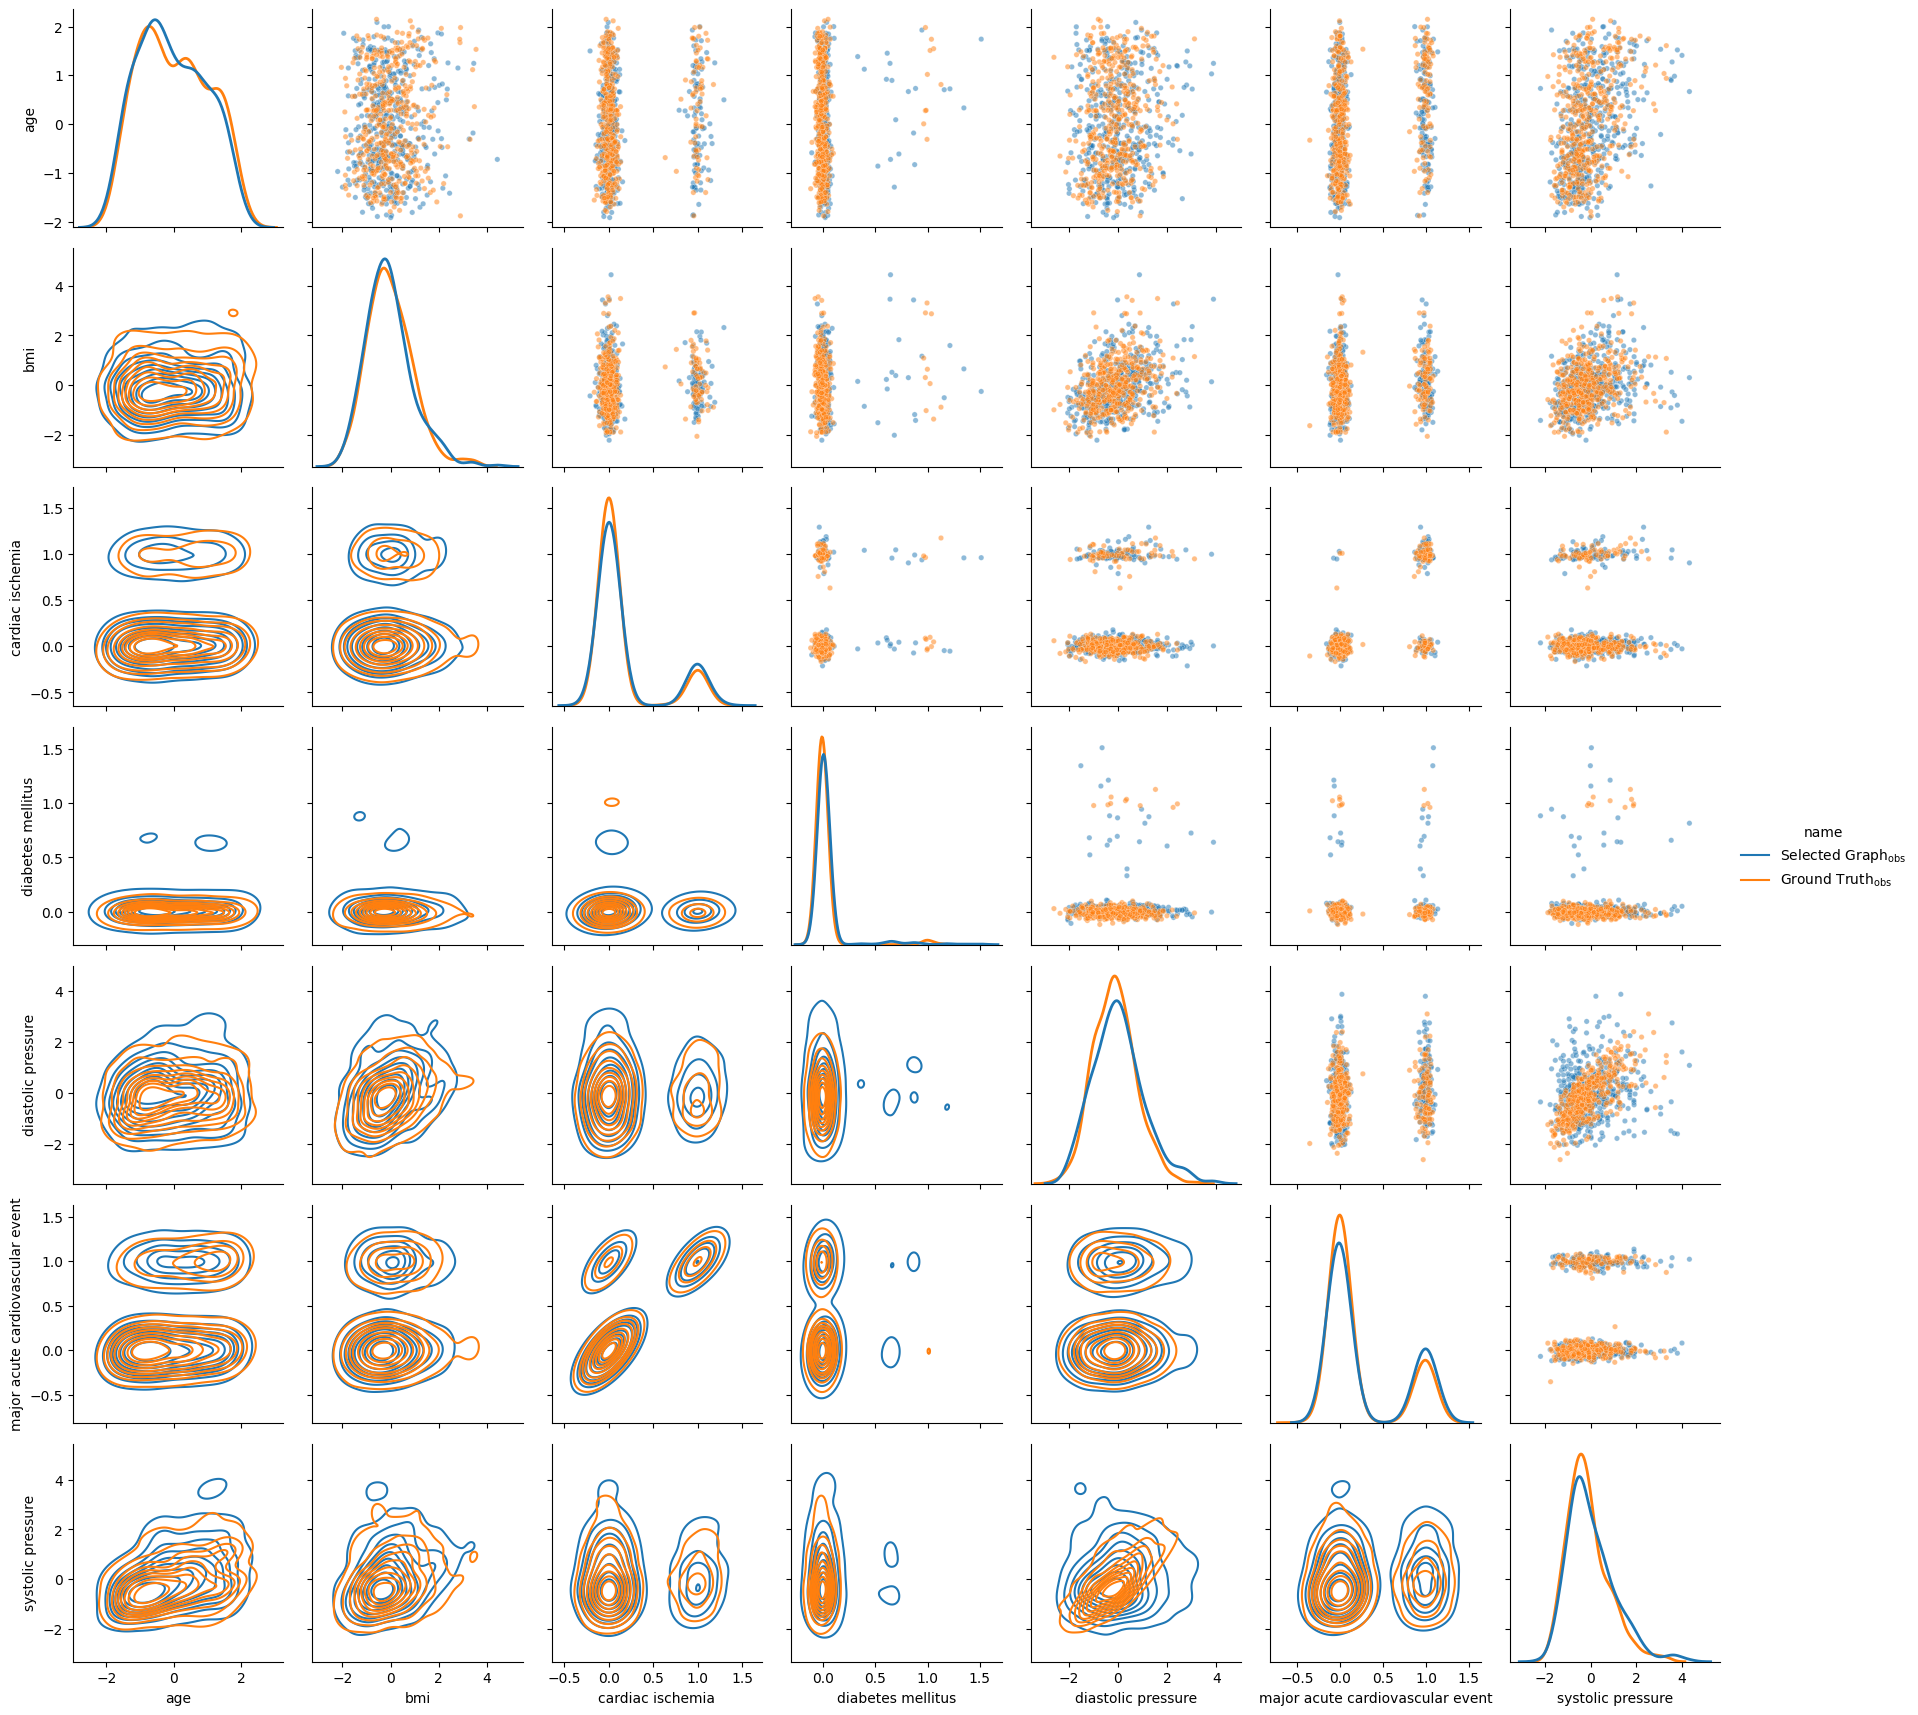

In [202]:
# bien
plot_data({
    r'$\text{Selected Graph}_{\text{obs}}$': gen_data_selected,
    r'$\text{Ground Truth}_{\text{obs}}$': gen_data_gt,})


# buena intervencion systolic pressure intervention bmi

In [162]:
bmi_mean = scaler.mean_[1]
bmi_std = np.sqrt(scaler.var_[1])


In [189]:
outcome_var = 'diabetes mellitus'
outcome_index = variables.index(outcome_var)
intervention_values = [24.0, 30.0]  # BMI low vs high, obesity vs non obesity
intervention_values = [float((val - bmi_mean) / bmi_std) for val in intervention_values]
intervention_values

[-0.4490203421278074, 1.0155282666023218]

problema que intervention values no estaba normalizado, tengo que normalizar porque mi modelo entiende en el rango normalizado, 
`pero luego tengo que desnormalizar, despues de hacer la intervencion y generar las muestras, para ver los resultados en el rango original, la mean debe dar

#TODO 

ACLARAR INDICES DE VARIABLES CONTINUAS PARA NORMALIZAR Y DESNORMALIZAR 
mirar las que entren y salgan de mi modelo

tiene que haber algo de mapeo entre indice de variables que son las del grafo e indices del dataframe que yo meto
los indices de las variables del grafo van a cambiar porque mi grafo cambia

automatizar 


Intervention and outcome in systolic pressure

In [184]:
outcome_var = 'systolic pressure'
outcome_index = variables.index(outcome_var)

continuous_indices_in_data = [data_df.columns.get_loc(c) for c in continuous_vars] if len(continuous_vars) > 0 else []

# Selected graph ATE
samples_0_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_selected_denorm = samples_0_selected.copy()
samples_1_selected_denorm = samples_1_selected.copy()

if len(continuous_indices_in_data) > 0:
    # samples_0_selected_denorm[:, continuous_indices_in_data] = (
    #     samples_0_selected[:, continuous_indices_in_data] * scaler.scale_ + scaler.mean_
    # )
    # samples_1_selected_denorm[:, continuous_indices_in_data] = (
    #     samples_1_selected[:, continuous_indices_in_data] * scaler.scale_ + scaler.mean_
    # )

    samples_0_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_selected[:, continuous_indices_in_data]
    )
    samples_1_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_selected[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_selected = samples_0_selected_denorm[:, outcome_index].mean()
    mean_1_selected = samples_1_selected_denorm[:, outcome_index].mean()
else:
    mean_0_selected = samples_0_selected[:, outcome_index].clip(0, 1).round().mean()
    mean_1_selected = samples_1_selected[:, outcome_index].clip(0, 1).round().mean()

ate_selected = mean_1_selected - mean_0_selected

# Ground truth ATE
samples_0_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_gt_denorm = samples_0_gt.copy()
samples_1_gt_denorm = samples_1_gt.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_gt[:, continuous_indices_in_data]
    )
    samples_1_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_gt[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_gt = samples_0_gt_denorm[:, outcome_index].mean()
    mean_1_gt = samples_1_gt_denorm[:, outcome_index].mean()
else:
    mean_0_gt = samples_0_gt[:, outcome_index].clip(0, 1).round().mean()
    mean_1_gt = samples_1_gt[:, outcome_index].clip(0, 1).round().mean()

ate_gt = mean_1_gt - mean_0_gt


print(f"\nSelected Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
print(f"   ATE = {ate_selected:+.2f}")

print(f"\nGround Truth Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
print(f"   ATE = {ate_gt:+.2f}")


print(f"\nDifference ATE:")
if outcome_var in continuous_vars:
    print(f"   ATE_selected - ATE_gt= {abs(ate_selected - ate_gt):.2f}")
else:
    print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.1%}")


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 131.35
   E[systolic pressure | do(bmi=1.02)] = 138.99
   ATE = +7.64

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.69
   E[systolic pressure | do(bmi=1.02)] = 138.68
   ATE = +8.00

Difference ATE:
   ATE_selected - ATE_gt= 0.36


In [66]:
outcome_var = 'systolic pressure'
outcome_index = variables.index(outcome_var)

continuous_indices_in_data = [data_df.columns.get_loc(c) for c in continuous_vars] if len(continuous_vars) > 0 else []

# Selected graph ATE
samples_0_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_selected_denorm = samples_0_selected.copy()
samples_1_selected_denorm = samples_1_selected.copy()

if len(continuous_indices_in_data) > 0:
    # samples_0_selected_denorm[:, continuous_indices_in_data] = (
    #     samples_0_selected[:, continuous_indices_in_data] * scaler.scale_ + scaler.mean_
    # )
    # samples_1_selected_denorm[:, continuous_indices_in_data] = (
    #     samples_1_selected[:, continuous_indices_in_data] * scaler.scale_ + scaler.mean_
    # )

    samples_0_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_selected[:, continuous_indices_in_data]
    )
    samples_1_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_selected[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_selected = samples_0_selected_denorm[:, outcome_index].mean()
    mean_1_selected = samples_1_selected_denorm[:, outcome_index].mean()
else:
    mean_0_selected = samples_0_selected[:, outcome_index].clip(0, 1).round().mean()
    mean_1_selected = samples_1_selected[:, outcome_index].clip(0, 1).round().mean()

ate_selected = mean_1_selected - mean_0_selected

# Ground truth ATE
samples_0_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_gt_denorm = samples_0_gt.copy()
samples_1_gt_denorm = samples_1_gt.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_gt[:, continuous_indices_in_data]
    )
    samples_1_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_gt[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_gt = samples_0_gt_denorm[:, outcome_index].mean()
    mean_1_gt = samples_1_gt_denorm[:, outcome_index].mean()
else:
    mean_0_gt = samples_0_gt[:, outcome_index].clip(0, 1).round().mean()
    mean_1_gt = samples_1_gt[:, outcome_index].clip(0, 1).round().mean()

ate_gt = mean_1_gt - mean_0_gt


print(f"\nSelected Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
print(f"   ATE = {ate_selected:+.2f}")

print(f"\nGround Truth Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
print(f"   ATE = {ate_gt:+.2f}")


print(f"\nDifference ATE:")
if outcome_var in continuous_vars:
    print(f"   ATE_selected - ATE_gt= {abs(ate_selected - ate_gt):.2f}")
else:
    print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.1%}")


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 0.24
   E[systolic pressure | do(bmi=1.02)] = 0.34
   ATE = +0.09

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = -0.06
   E[systolic pressure | do(bmi=1.02)] = 0.33
   ATE = +0.39

Difference ATE:
   ATE_selected - ATE_gt= 0.29


In [57]:
loaded_models[0]['variables']

['age',
 'bmi',
 'cardiac ischemia',
 'diabetes mellitus',
 'diastolic pressure',
 'major acute cardiovascular event',
 'systolic pressure']

# try intervention in diabetes 

In [190]:
intervention_values = [0.0, 1.0]  # diabetes non normalization

In [ ]:
outcome_var = 'cardiac ischemia'
outcome_index = variables.index(outcome_var)

continuous_indices_in_data = [data_df.columns.get_loc(c) for c in continuous_vars] if len(continuous_vars) > 0 else []

# Selected graph ATE
samples_0_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_selected_denorm = samples_0_selected.copy()
samples_1_selected_denorm = samples_1_selected.copy()

if len(continuous_indices_in_data) > 0:
    # samples_0_selected_denorm[:, continuous_indices_in_data] = (
    #     samples_0_selected[:, continuous_indices_in_data] * scaler.scale_ + scaler.mean_
    # )
    # samples_1_selected_denorm[:, continuous_indices_in_data] = (
    #     samples_1_selected[:, continuous_indices_in_data] * scaler.scale_ + scaler.mean_
    # )

    samples_0_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_selected[:, continuous_indices_in_data]
    )
    samples_1_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_selected[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_selected = samples_0_selected_denorm[:, outcome_index].mean()
    mean_1_selected = samples_1_selected_denorm[:, outcome_index].mean()
else:
    mean_0_selected = samples_0_selected[:, outcome_index].clip(0, 1).round().mean()
    mean_1_selected = samples_1_selected[:, outcome_index].clip(0, 1).round().mean()

ate_selected = mean_1_selected - mean_0_selected

# Ground truth ATE
samples_0_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_gt_denorm = samples_0_gt.copy()
samples_1_gt_denorm = samples_1_gt.copy()


samples_0_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
    samples_0_gt[:, continuous_indices_in_data]
)
samples_1_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
    samples_1_gt[:, continuous_indices_in_data]
)

if outcome_var in continuous_vars:
    mean_0_gt = samples_0_gt_denorm[:, outcome_index].mean()
    mean_1_gt = samples_1_gt_denorm[:, outcome_index].mean()
else:
    mean_0_gt = samples_0_gt[:, outcome_index].clip(0, 1).round().mean()
    mean_1_gt = samples_1_gt[:, outcome_index].clip(0, 1).round().mean()

ate_gt = mean_1_gt - mean_0_gt


print(f"\nSelected Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
print(f"   ATE = {ate_selected:+.2f}")

print(f"\nGround Truth Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
print(f"   ATE = {ate_gt:+.2f}")


print(f"\nDifference ATE:")
if outcome_var in continuous_vars:
    print(f"   |ATE_selected - ATE_gt| = {abs(ate_selected - ate_gt):.2f}")
else:
    # Para variables binarias, mostramos tanto el valor absoluto como el porcentaje
    diff = abs(ate_selected - ate_gt)
    print(f"   |ATE_selected - ATE_gt| = {diff:.3f} (diferencia en probabilidad)")
    print(f"   En porcentaje: {diff:.1%}")


Selected Graph:
   E[cardiac ischemia | do(bmi=0.00)] = 0.18
   E[cardiac ischemia | do(bmi=1.00)] = 0.21
   ATE = +0.03

Ground Truth Graph:
   E[cardiac ischemia | do(bmi=0.00)] = 0.20
   E[cardiac ischemia | do(bmi=1.00)] = 0.24
   ATE = +0.04

Difference ATE:
   |ATE_selected - ATE_gt| = 0.007 (diferencia en probabilidad)
   En porcentaje: 0.7%


### 2a parte FUNCTION FIT with early stopping

In [59]:
def fit(
    flow: nn.Module,
    train_data: TensorLike,
    val_data: Optional[TensorLike] = None,
    *,
    lr: float = 1e-3,
    batch_size: int = 256,
    epochs: int = 100,
    device: Optional[torch.device] = None,
    print_every: int = 1,
    early_stopping_patience: int = 0,
    early_stopping_min_delta: float = 1e-4,
) -> Dict[str, Any]:
    """
    Training loop for a flow model with .log_prob(x) and early stopping.
    """
    dev = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    flow.to(dev)

    train_loader = _make_loader(train_data, batch_size, shuffle=True)
    val_loader = _make_loader(val_data, batch_size, shuffle=False) if val_data is not None else None

    optim = torch.optim.Adam(flow.parameters(), lr=lr)

    history = {
        "train_nll": [], 
        "val_nll": [] if val_loader is not None else None,
        "stopped_early": False,
        "best_epoch": 0
    }
    
    best_val_nll = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in tqdm(range(1, epochs + 1)):
        flow.train()
        running, seen = 0.0, 0

        for batch in train_loader:
            x = batch[0] if isinstance(batch, (tuple, list)) else batch
            x = x.to(dev, non_blocking=True)

            optim.zero_grad(set_to_none=True)
            loss = -flow().log_prob(x).mean()
            loss.backward()
            optim.step()

            running += float(loss.item()) * x.size(0)
            seen += x.size(0)

        train_nll = running / max(seen, 1)
        history["train_nll"].append(train_nll)

        if val_loader is not None:
            val_nll = _eval_nll(flow, val_loader, dev)
            history["val_nll"].append(val_nll)
            
            if early_stopping_patience > 0:
                if val_nll < best_val_nll - early_stopping_min_delta:
                    best_val_nll = val_nll
                    patience_counter = 0
                    history["best_epoch"] = epoch
                    best_model_state = {k: v.cpu().clone() for k, v in flow.state_dict().items()}
                else:
                    patience_counter += 1
                    
                if patience_counter >= early_stopping_patience:
                    print(f"\n[{epoch:03d}/{epochs:03d}] Early stopping triggered!")
                    print(f"   train_nll={train_nll:.4f}  val_nll={val_nll:.4f}")
                    print(f"   Best epoch: {history['best_epoch']}, Best val_nll: {best_val_nll:.4f}")
                    history["stopped_early"] = True
                    if best_model_state is not None:
                        flow.load_state_dict(best_model_state)
                    break
            
            if epoch % print_every == 0:
                patience_str = f"  patience={patience_counter}/{early_stopping_patience}" if early_stopping_patience > 0 else ""
                print(f"[{epoch:03d}/{epochs:03d}] train_nll={train_nll:.4f}  val_nll={val_nll:.4f}{patience_str}")
        else:
            if epoch % print_every == 0:
                print(f"[{epoch:03d}/{epochs:03d}] train_nll={train_nll:.4f}")

    return history

In [60]:
# Load graphs
with open("new_ordered_graphs.json", 'r', encoding='utf-8') as f:
    loaded_graphs = json.load(f)

In [61]:
loaded_graphs=loaded_graphs[0:2]

In [15]:
data_df_original = pd.read_csv("TFM_dataset.csv")
data_df_original = data_df_original.drop(columns=['randid'])
bmi_mode = data_df_original['bmi'].mode()[0]
data_df_original['bmi'] = data_df_original['bmi'].fillna(bmi_mode)


In [16]:
with open("ground_truth_graph.json", 'r', encoding='utf-8') as f:
    ground_truth_data = json.load(f)

adjacency_gt = np.array(ground_truth_data['adjacency_matrix'])
np.fill_diagonal(adjacency_gt, 1)
adjacency_gt = torch.tensor(adjacency_gt, dtype=torch.bool)

gt_variables = ground_truth_data['variables']
gt_variables

['age',
 'bmi',
 'diabetes mellitus',
 'cardiac ischemia',
 'diastolic pressure',
 'systolic pressure',
 'major acute cardiovascular event']

In [21]:
# Load data from scratch (original)
data_df = pd.read_csv("TFM_dataset.csv")
data_df = data_df.drop(columns=['randid'])

# Fill missing BMI values with mode
bmi_mode = data_df['bmi'].mode()[0]
data_df['bmi'] = data_df['bmi'].fillna(bmi_mode)

# Identify binary/continuous variables (once)
binary_vars = []
for col in data_df.columns:
    unique_vals = sorted(data_df[col].unique())
    if len(unique_vals) == 2 and set(unique_vals).issubset({0.0, 1.0}):
        binary_vars.append(col)

continuous_vars = [col for col in data_df.columns if col not in binary_vars]

# Split data (before any processing)
diabetes_labels = data_df['diabetes mellitus'].values

# First split: separate test set (10%)
train_val_idx, test_idx = train_test_split(
    np.arange(len(data_df)),
    test_size=0.1,
    stratify=diabetes_labels,
    random_state=42
)

# Second split: separate validation set from training 
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.11,  # ~10% of total for validation
    stratify=diabetes_labels[train_val_idx],
    random_state=42
)

# Configuration
cfg_balanced = {
    'hidden_dims': [32, 32],
    'lr': 1e-3,
    'batch_size': 256,
    'epochs': 1000,
    'early_stopping_patience': 100,
    'early_stopping_min_delta': 1e-4,
}

context = 0

# Create directories for saving models
import os
os.makedirs('new_saved_models', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

print("Training Ground Truth Flow Model")

# 1. Reorder to GT variable order
data_gt = data_df[gt_variables].copy()

# 2. FIT scaler ONLY on training data (prevent data leakage)
scaler_gt = StandardScaler()
data_norm_gt = data_gt.copy()
gt_continuous = [v for v in gt_variables if v in continuous_vars]

if len(gt_continuous) > 0:
    gt_cont_indices = [gt_variables.index(v) for v in gt_continuous]
    
    # FIT only on training data
    scaler_gt.fit(data_gt.iloc[train_idx][gt_continuous])
    
    # TRANSFORM all data (train, val, test)
    data_norm_gt.iloc[:, gt_cont_indices] = scaler_gt.transform(data_gt[gt_continuous])

# 3. Add noise to binary variables
np.random.seed(42)
for col in binary_vars:
    if col in gt_variables:
        noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
        noise = np.random.normal(0, noise_std, size=len(data_df))
        data_norm_gt[col] = data_gt[col].astype(float) + noise

# 4. Create tensors (train, val, test)
data_tensor_gt = torch.tensor(data_norm_gt.values, dtype=torch.float32)
train_data_gt = data_tensor_gt[train_idx]
val_data_gt = data_tensor_gt[val_idx]
test_data_gt = data_tensor_gt[test_idx]

# 5. Train GT model with early stopping
features = len(gt_variables)
flow_gt = CausalNSF(
    features,
    context,
    adjacency=adjacency_gt,
    hidden_features=cfg_balanced['hidden_dims']
)

history_gt = fit(
    flow_gt,
    train_data_gt,
    val_data=val_data_gt,
    lr=cfg_balanced['lr'],
    batch_size=cfg_balanced['batch_size'],
    epochs=cfg_balanced['epochs'],
    print_every=200,
    early_stopping_patience=cfg_balanced['early_stopping_patience'],
    early_stopping_min_delta=cfg_balanced['early_stopping_min_delta'],
)

# 6. Evaluate on test set (final evaluation)
test_nll_gt = _eval_nll(flow_gt, _make_loader(test_data_gt, cfg_balanced['batch_size'], False),
                        torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# Print summary for GT model
if history_gt.get('stopped_early', False):
    print(f"Ground Truth Model: Early stopping at epoch {len(history_gt['train_nll'])}")
    print(f"  Best epoch: {history_gt['best_epoch']}, Best val_nll: {min(history_gt['val_nll']):.4f}")
else:
    print(f"Ground Truth Model: Completed all {cfg_balanced['epochs']} epochs")
print(f"  Test NLL: {test_nll_gt:.4f}")

# Save ground truth model
model_path_gt = 'saved_models/flow_ground_truth.pt'
torch.save({
    'model_state_dict': flow_gt.state_dict(),
    'adjacency': adjacency_gt,
    'variables': gt_variables,
    'features': len(gt_variables),
    'config': cfg_balanced,
    'history': history_gt,
    'test_nll': test_nll_gt,
    'scaler': scaler_gt,
}, model_path_gt)
print(f"Saved ground truth model to {model_path_gt}")

print("\nGround Truth Model Training Complete\n")

# Train selected graph models
for graph_idx, selected_graph in enumerate(loaded_graphs):
    print(f"Processing Graph {graph_idx + 1}/{len(loaded_graphs)}")

    variables = selected_graph['variables']
    adjacency_matrix = selected_graph['adjacency_matrix']

    adj_array = np.array(adjacency_matrix)
    np.fill_diagonal(adj_array, 1)
    adjacency = torch.tensor(adj_array, dtype=torch.bool)

    # 1. Reorder to selected graph variable order
    data_selected = data_df[variables].copy()

    # 2. FIT scaler ONLY on training data (prevent data leakage)
    scaler_selected = StandardScaler()
    data_norm_selected = data_selected.copy()
    sel_continuous = [v for v in variables if v in continuous_vars]
    
    if len(sel_continuous) > 0:
        sel_cont_indices = [variables.index(v) for v in sel_continuous]
        
        # FIT only on training data
        scaler_selected.fit(data_selected.iloc[train_idx][sel_continuous])
        
        # TRANSFORM all data
        data_norm_selected.iloc[:, sel_cont_indices] = scaler_selected.transform(data_selected[sel_continuous])

    # 3. Add noise to binary variables (same seed for consistency)
    np.random.seed(42)
    for col in binary_vars:
        if col in variables:
            noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
            noise = np.random.normal(0, noise_std, size=len(data_df))
            data_norm_selected[col] = data_selected[col].astype(float) + noise

    # 4. Create tensors (train, val, test)
    data_tensor = torch.tensor(data_norm_selected.values, dtype=torch.float32)
    train_data = data_tensor[train_idx]
    val_data = data_tensor[val_idx]
    test_data = data_tensor[test_idx]

    # 5. Train selected graph model with early stopping
    flow = CausalNSF(
        len(variables),
        context,
        adjacency=adjacency,
        hidden_features=cfg_balanced['hidden_dims']
    )

    history = fit(
        flow,
        train_data,
        val_data=val_data,
        lr=cfg_balanced['lr'],
        batch_size=cfg_balanced['batch_size'],
        epochs=cfg_balanced['epochs'],
        print_every=200,
        early_stopping_patience=cfg_balanced['early_stopping_patience'],
        early_stopping_min_delta=cfg_balanced['early_stopping_min_delta'],
    )
    
    # 6. Evaluate on test set (final evaluation)
    test_nll = _eval_nll(flow, _make_loader(test_data, cfg_balanced['batch_size'], False),
                         torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    
    # Print summary for selected graph
    if history.get('stopped_early', False):
        print(f"Graph {graph_idx}: Early stopping at epoch {len(history['train_nll'])}")
        print(f"  Best epoch: {history['best_epoch']}, Best val_nll: {min(history['val_nll']):.4f}")
    else:
        print(f"Graph {graph_idx}: Completed all {cfg_balanced['epochs']} epochs")
    print(f"  Test NLL: {test_nll:.4f}")
    
    # 7. Save model with its scaler
    model_path_selected = f'new_saved_models/flow_selected_graph_{graph_idx}.pt'
    torch.save({
        'model_state_dict': flow.state_dict(),
        'adjacency': adjacency,
        'variables': variables,
        'features': len(variables),
        'config': cfg_balanced,
        'history': history,
        'test_nll': test_nll,
        'scaler': scaler_selected,
    }, model_path_selected)
    print(f"Saved selected graph model to {model_path_selected}\n")

print("ALL MODELS TRAINED")

/tmp/ipykernel_30374/1631496704.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.26386182 -0.46139399 -0.23211746 ...  0.22643559 -1.14922356
 -1.26386182]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_norm_gt.iloc[:, gt_cont_indices] = scaler_gt.transform(data_gt[gt_continuous])
/tmp/ipykernel_30374/1631496704.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.08402598 -0.18519266 -0.26690478 ... -0.02176842  1.20391338
  0.22336794]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_norm_gt.iloc[:, gt_cont_indices] = scaler_gt.transform(data_gt[gt_continuous])
/tmp/ipykernel_30374/1631496704.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.20488508 -0.5403975

Training Ground Truth Flow Model


  0%|          | 0/1000 [00:00<?, ?it/s]

/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 20%|██        | 201/1000 [00:17<01:15, 10.53it/s]

[200/1000] train_nll=0.5594  val_nll=0.5912  patience=5/100


...

[200/1000] train_nll=0.9202  val_nll=0.8809  patience=0/100


 40%|████      | 401/1000 [00:35<00:54, 11.05it/s]

[400/1000] train_nll=0.8866  val_nll=0.8842  patience=33/100


 56%|█████▌    | 555/1000 [00:50<00:40, 11.02it/s]


[556/1000] Early stopping triggered!
   train_nll=0.8621  val_nll=0.8735
   Best epoch: 456, Best val_nll: 0.8486
Graph 1: Early stopping at epoch 556
  Best epoch: 456, Best val_nll: 0.8486
  Test NLL: 0.6994
Saved selected graph model to new_saved_models/flow_selected_graph_1.pt

ALL MODELS TRAINED


In [50]:
# Save ground truth model ONCE (outside the loop)


model_path_gt = 'new_saved_models_final/flow_ground_truth.pt'
torch.save({
    'model_state_dict': flow_gt.state_dict(),
    'adjacency': adjacency_gt,
    'variables': gt_variables,
    'features': len(gt_variables),
    'config': cfg_balanced,
    'history': history_gt,
    'scaler': scaler_gt,  # ✅ Guardar el scaler del GT
}, model_path_gt)
print(f"Saved ground truth model to {model_path_gt}\n")

Saved ground truth model to new_saved_models_final/flow_ground_truth.pt



Loading trained models

In [53]:
# # Load all models
# loaded_models = []

# for graph_idx in range(len(loaded_graphs)):
#     # Load selected graph model
#     checkpoint_selected = torch.load(f'new_saved_models_final/flow_selected_graph_{graph_idx}.pt')
#     flow_selected = CausalNSF(
#         checkpoint_selected['features'],
#         0,
#         adjacency=checkpoint_selected['adjacency'],
#         hidden_features=checkpoint_selected['config']['hidden_dims']
#     )
#     flow_selected.load_state_dict(checkpoint_selected['model_state_dict'])
#     flow_selected.eval()
    
#     # Load ground truth model
#     checkpoint_gt = torch.load(f'saved_models/flow_ground_truth.pt')
#     flow_gt = CausalNSF(
#         checkpoint_gt['features'],
#         0,
#         adjacency=checkpoint_gt['adjacency'],
#         hidden_features=checkpoint_gt['config']['hidden_dims']
#     )
#     flow_gt.load_state_dict(checkpoint_gt['model_state_dict'])
#     flow_gt.eval()
    
#     loaded_models.append({
#         'flow_selected': flow_selected,
#         'flow_gt': flow_gt,
#         'variables': checkpoint_selected['variables']
#     })

# print(f"Loaded {len(loaded_models)} model pairs")

# Load all models
loaded_models = []

# Determine device (CPU or CUDA)
device = torch.device('cpu')  # Force CPU loading

for graph_idx in range(len(loaded_graphs)):
    # Load selected graph model with map_location and weights_only=False
    checkpoint_selected = torch.load(
        f'new_saved_models_final/flow_selected_graph_{graph_idx}.pt',
        map_location=device,
        weights_only=False  # Allow non-tensor objects like StandardScaler
    )
    flow_selected = CausalNSF(
        checkpoint_selected['features'],
        0,
        adjacency=checkpoint_selected['adjacency'],
        hidden_features=checkpoint_selected['config']['hidden_dims']
    )
    flow_selected.load_state_dict(checkpoint_selected['model_state_dict'])
    flow_selected.eval()
    
    # Load ground truth model with map_location (only once)
    if graph_idx == 0:
        checkpoint_gt = torch.load(
            f'saved_models/flow_ground_truth.pt',
            map_location=device,
            weights_only=False  # Allow non-tensor objects
        )
        flow_gt = CausalNSF(
            checkpoint_gt['features'],
            0,
            adjacency=checkpoint_gt['adjacency'],
            hidden_features=checkpoint_gt['config']['hidden_dims']
        )
        flow_gt.load_state_dict(checkpoint_gt['model_state_dict'])
        flow_gt.eval()
    
    loaded_models.append({
        'flow_selected': flow_selected,
        'flow_gt': flow_gt,
        'variables': checkpoint_selected['variables'],
        'scaler': checkpoint_selected['scaler']  # Load scaler too
    })

print(f"Loaded {len(loaded_models)} model pairs")

Loaded 2 model pairs


In [54]:
flow_prueba= loaded_models[0]
variables = flow_prueba['variables']  # Selected graph variable order
flow_selected = flow_prueba['flow_selected']

In [57]:
bmi_mean = scaler.mean_[1]
bmi_std = np.sqrt(scaler.var_[1])

intervention_values = [24.0, 30.0]  # BMI low vs high, obesity vs non obesity
intervention_values = [float((val - bmi_mean) / bmi_std) for val in intervention_values]
intervention_values
intervention_var = 'bmi'  
intervention_index = variables.index(intervention_var)
test_size = test_data.shape[0]

In [58]:
outcome_var = 'systolic pressure'
outcome_index = variables.index(outcome_var)
outcome_index = variables.index(outcome_var)
continuous_indices_in_data = [data_df.columns.get_loc(c) for c in continuous_vars] if len(continuous_vars) > 0 else []

# Selected graph ATE
samples_0_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_selected = flow().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_selected_denorm = samples_0_selected.copy()
samples_1_selected_denorm = samples_1_selected.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_selected[:, continuous_indices_in_data]
    )
    samples_1_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_selected[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_selected = samples_0_selected_denorm[:, outcome_index].mean()
    mean_1_selected = samples_1_selected_denorm[:, outcome_index].mean()
else:
    mean_0_selected = samples_0_selected[:, outcome_index].clip(0, 1).round().mean()
    mean_1_selected = samples_1_selected[:, outcome_index].clip(0, 1).round().mean()

ate_selected = mean_1_selected - mean_0_selected

# Ground truth ATE
samples_0_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_gt_denorm = samples_0_gt.copy()
samples_1_gt_denorm = samples_1_gt.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_gt[:, continuous_indices_in_data]
    )
    samples_1_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_gt[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_gt = samples_0_gt_denorm[:, outcome_index].mean()
    mean_1_gt = samples_1_gt_denorm[:, outcome_index].mean()
else:
    mean_0_gt = samples_0_gt[:, outcome_index].clip(0, 1).round().mean()
    mean_1_gt = samples_1_gt[:, outcome_index].clip(0, 1).round().mean()

ate_gt = mean_1_gt - mean_0_gt


print(f"\nSelected Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
print(f"   ATE = {ate_selected:+.2f}")

print(f"\nGround Truth Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
print(f"   ATE = {ate_gt:+.2f}")


print(f"\nDifference ATE:")
if outcome_var in continuous_vars:
    print(f"   ATE_selected - ATE_gt= {abs(ate_selected - ate_gt):.2f}")
else:
    print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.1%}")


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 0.26
   E[systolic pressure | do(bmi=1.02)] = 0.31
   ATE = +0.06

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = -0.08
   E[systolic pressure | do(bmi=1.02)] = 0.26
   ATE = +0.35

Difference ATE:
   ATE_selected - ATE_gt= 0.29


prueba

In [65]:
# Load data from scratch (original)
data_df = pd.read_csv("TFM_dataset.csv")
data_df = data_df.drop(columns=['randid'])

# Fill missing BMI values with mode
bmi_mode = data_df['bmi'].mode()[0]
data_df['bmi'] = data_df['bmi'].fillna(bmi_mode)

# Identify binary/continuous variables (once)
binary_vars = []
for col in data_df.columns:
    unique_vals = sorted(data_df[col].unique())
    if len(unique_vals) == 2 and set(unique_vals).issubset({0.0, 1.0}):
        binary_vars.append(col)

continuous_vars = [col for col in data_df.columns if col not in binary_vars]

# Split data (before any processing)
diabetes_labels = data_df['diabetes mellitus'].values

# First split: separate test set (10%)
train_val_idx, test_idx = train_test_split(
    np.arange(len(data_df)),
    test_size=0.1,
    stratify=diabetes_labels,
    random_state=42
)

# Second split: separate validation set from training 
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.11,  # ~10% of total for validation
    stratify=diabetes_labels[train_val_idx],
    random_state=42
)

# Configuration
cfg_balanced = {
    'hidden_dims': [32, 32],
    'lr': 1e-3,
    'batch_size': 256,
    'epochs': 1000,
    'early_stopping_patience': 100,
    'early_stopping_min_delta': 1e-4,
}

context = 0

# Create directories for saving models
import os
os.makedirs('new_saved_models', exist_ok=True)

print("Training Ground Truth Flow Model")

# 1. Reorder to GT variable order
data_gt = data_df[gt_variables].copy()

# 2. FIT_TRANSFORM scaler on ALL data (same as selected graphs)
scaler_gt = StandardScaler()
data_norm_gt = data_gt.copy()
gt_continuous = [v for v in gt_variables if v in continuous_vars]

if len(gt_continuous) > 0:
    gt_cont_indices = [gt_variables.index(v) for v in gt_continuous]
    # FIT_TRANSFORM on all data
    data_norm_gt.iloc[:, gt_cont_indices] = scaler_gt.fit_transform(data_gt[gt_continuous])

# 3. Add noise to binary variables
np.random.seed(42)
for col in binary_vars:
    if col in gt_variables:
        noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
        noise = np.random.normal(0, noise_std, size=len(data_df))
        data_norm_gt[col] = data_gt[col].astype(float) + noise

# 4. Create tensors (train, val, test)
data_tensor_gt = torch.tensor(data_norm_gt.values, dtype=torch.float32)
train_data_gt = data_tensor_gt[train_idx]
val_data_gt = data_tensor_gt[val_idx]
test_data_gt = data_tensor_gt[test_idx]

# 5. Train GT model with early stopping
features = len(gt_variables)
flow_gt = CausalNSF(
    features,
    context,
    adjacency=adjacency_gt,
    hidden_features=cfg_balanced['hidden_dims']
)

history_gt = fit(
    flow_gt,
    train_data_gt,
    val_data=val_data_gt,
    lr=cfg_balanced['lr'],
    batch_size=cfg_balanced['batch_size'],
    epochs=cfg_balanced['epochs'],
    print_every=200,
    early_stopping_patience=cfg_balanced['early_stopping_patience'],
    early_stopping_min_delta=cfg_balanced['early_stopping_min_delta'],
)

# 6. Evaluate on test set (final evaluation)
test_nll_gt = _eval_nll(flow_gt, _make_loader(test_data_gt, cfg_balanced['batch_size'], False),
                        torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# Print summary for GT model
if history_gt.get('stopped_early', False):
    print(f"Ground Truth Model: Early stopping at epoch {len(history_gt['train_nll'])}")
    print(f"  Best epoch: {history_gt['best_epoch']}, Best val_nll: {min(history_gt['val_nll']):.4f}")
else:
    print(f"Ground Truth Model: Completed all {cfg_balanced['epochs']} epochs")
print(f"  Test NLL: {test_nll_gt:.4f}")

# Save ground truth model
model_path_gt = 'new_saved_models/flow_ground_truth.pt'
torch.save({
    'model_state_dict': flow_gt.state_dict(),
    'adjacency': adjacency_gt,
    'variables': gt_variables,
    'features': len(gt_variables),
    'config': cfg_balanced,
    'history': history_gt,
    'test_nll': test_nll_gt,
    'scaler': scaler_gt,
}, model_path_gt)
print(f"Saved ground truth model to {model_path_gt}")

print("\nGround Truth Model Training Complete\n")

/tmp/ipykernel_30374/3851211062.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.25932027 -0.45249227 -0.22196998 ...  0.23907459 -1.14405912
 -1.25932027]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_norm_gt.iloc[:, gt_cont_indices] = scaler_gt.fit_transform(data_gt[gt_continuous])
/tmp/ipykernel_30374/3851211062.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.09245627 -0.17959929 -0.26258628 ... -0.01362529  1.23117969
  0.23533571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_norm_gt.iloc[:, gt_cont_indices] = scaler_gt.fit_transform(data_gt[gt_continuous])
/tmp/ipykernel_30374/3851211062.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.20464005e+0

Training Ground Truth Flow Model


  0%|          | 0/1000 [00:00<?, ?it/s]/home/moleropa/miniforge3/envs/tfmenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 20%|██        | 201/1000 [00:22<01:25,  9.31it/s]

[200/1000] train_nll=0.5203  val_nll=0.4557  patience=5/100


 40%|████      | 401/1000 [00:52<00:58, 10.31it/s]

[400/1000] train_nll=0.4748  val_nll=0.5035  patience=7/100


 49%|████▉     | 492/1000 [01:04<01:06,  7.59it/s]


[493/1000] Early stopping triggered!
   train_nll=0.4787  val_nll=0.4747
   Best epoch: 393, Best val_nll: 0.4374
Ground Truth Model: Early stopping at epoch 493
  Best epoch: 393, Best val_nll: 0.4374
  Test NLL: 0.2741
Saved ground truth model to new_saved_models/flow_ground_truth.pt

Ground Truth Model Training Complete

